In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

In [2]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "NEU-DET/train/images/",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "NEU-DET/validation/images/",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1152 images belonging to 6 classes.
Found 72 images belonging to 6 classes.


In [3]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False  # Freeze all layers

In [4]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')  # 6 classes
])

In [5]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(factor=0.2, patience=3)

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.1780 - loss: 1.9182 - val_accuracy: 0.1667 - val_loss: 1.7977 - learning_rate: 0.0010
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 986ms/step - accuracy: 0.1806 - loss: 1.7982 - val_accuracy: 0.1667 - val_loss: 1.7650 - learning_rate: 0.0010
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.2023 - loss: 1.7766 - val_accuracy: 0.4167 - val_loss: 1.7532 - learning_rate: 0.0010
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 999ms/step - accuracy: 0.2326 - loss: 1.7625 - val_accuracy: 0.2361 - val_loss: 1.7469 - learning_rate: 0.0010
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 33s 924ms/step - accuracy: 0.1988 - loss: 1.7634 - val_accuracy: 0.3472 - val_loss: 1.7331 - learning_rate: 0.0010
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 33s 917ms/step - accuracy: 0.2318 - loss: 1.7465 - val_accuracy: 0.3333 - val_loss: 1.7091 - learning_rate: 0.0010
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 33s 915ms/step - accuracy: 0.2266 - loss: 1.7418 -

In [7]:
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.2526 - loss: 1.8554 - val_accuracy: 0.2917 - val_loss: 1.4826
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.3472 - loss: 1.4767 - val_accuracy: 0.2083 - val_loss: 1.5894
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.3611 - loss: 1.4429 - val_accuracy: 0.1667 - val_loss: 2.3643
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.3767 - loss: 1.4149 - val_accuracy: 0.1389 - val_loss: 3.1924
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.3889 - loss: 1.3690 - val_accuracy: 0.2083 - val_loss: 4.2061
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.4097 - loss: 1.3696 - val_accuracy: 0.1111 - val_loss: 4.7411
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.4253 - loss: 1.3096 - val_accuracy: 0.2083 - val_loss: 4.4670
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.4679 - loss: 1.2709 - val_accuracy: 0.2222 - val_loss:

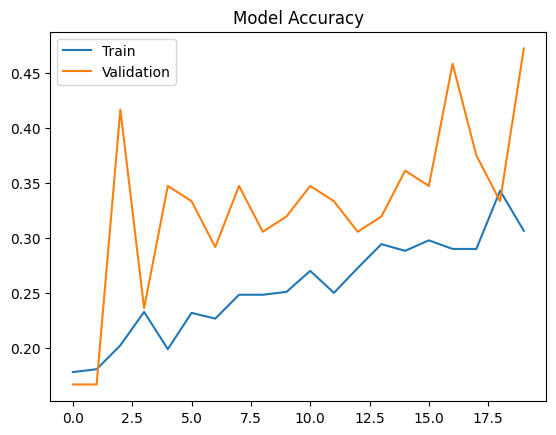

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Model Accuracy")
plt.show()